In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

sns.set_theme(style="whitegrid")

print("Расчет необходимого размера выборки (Power Analysis)\n")


alpha = 0.05
power = 0.80
baseline_cr = 0.12
expected_cr = 0.13

effect_size = sms.proportion_effectsize(baseline_cr, expected_cr)

required_n = sms.NormalIndPower().solve_power(
    effect_size=effect_size, 
    power=power, 
    alpha=alpha, 
    ratio=1.0
)

required_n = int(np.ceil(required_n))
print(f'Размер эффекта: {effect_size:.4f}')
print(f"Для детекции изменения конверсии с {baseline_cr*100}% до {expected_cr*100}%")
print(f"нам необходимо минимум {required_n} уникальных пользователей в каждой группе (всего: {required_n * 2}).")

Расчет необходимого размера выборки (Power Analysis)

Размер эффекта: -0.0302
Для детекции изменения конверсии с 12.0% до 13.0%
нам необходимо минимум 17164 уникальных пользователей в каждой группе (всего: 34328).


In [103]:
df = pd.read_csv('ab_data.csv')
print(f"Размер датасета: {df.shape}\n")
print(f"Всего уникальных пользователей в данных: {df['user_id'].nunique()}\n")
print(f"Распределение пользователей по группам:\n{df['group'].value_counts()}")

Размер датасета: (294480, 5)

Всего уникальных пользователей в данных: 290585

Распределение пользователей по группам:
group
treatment    147278
control      147202
Name: count, dtype: int64


In [104]:
df_clean = df[~(
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
)]
print(f"Размер датасета после удаления несоответствий: {df_clean.shape}\n")
print(f'общее количество несоответствий: {df.shape[0] - df_clean.shape[0]}')

Размер датасета после удаления несоответствий: (290587, 5)

общее количество несоответствий: 3893


In [105]:
user_group_counts = df_clean.groupby('user_id')['group'].nunique()
print(f"Количество пользователей, которые попали в обе группы: {user_group_counts[user_group_counts > 1].count()}")

Количество пользователей, которые попали в обе группы: 0


In [106]:
dublicate_users = df_clean.duplicated(subset='user_id')
print(f"Количество дубликатов пользователей: {dublicate_users.sum()}")
print(dublicate_users[dublicate_users].index)

Количество дубликатов пользователей: 2
Index([2893, 294478], dtype='int64')


In [107]:
duplicate_ids = df_clean[df_clean.duplicated(subset='user_id')]['user_id']
df_clean[df_clean['user_id'].isin(duplicate_ids)].sort_values(by='user_id')

,user_id,timestamp,group,landing_page,converted
250001,759899,07:36.1,treatment,new_page,0
294478,759899,20:29.0,treatment,new_page,0
1899,773192,37:58.8,treatment,new_page,0
2893,773192,55:59.6,treatment,new_page,0


In [108]:
df_final = df_clean.drop_duplicates(subset='user_id')

print(f"Итоговый объем выборки для анализа (df_final): {df_final.shape[0]} строк.")
print(f"Уникальных пользователей (проверка): {df_final['user_id'].nunique()}")
print("\nФинальное распределение пользователей по группам:")
print(df_final['group'].value_counts())

Итоговый объем выборки для анализа (df_final): 290585 строк.
Уникальных пользователей (проверка): 290585

Финальное распределение пользователей по группам:
group
treatment    145311
control      145274
Name: count, dtype: int64


In [109]:
conversion_stats = df_final.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
conversion_stats.columns = ['Всего пользователей', 'Конверсии (успехи)', 'Доля конверсии (CR)']
conversion_stats['CR %'] = conversion_stats['Доля конверсии (CR)'] * 100
print("\nСтатистика конверсии по группам:")
conversion_stats.round(4)


Статистика конверсии по группам:


,Всего пользователей,Конверсии (успехи),Доля конверсии (CR),CR %
group,,,,
control,145274,17489,0.1204,12.0386
treatment,145311,17264,0.1188,11.8807


/var/folders/dh/6dcwhgn974b1nbbyssb2221c0000gn/T/ipykernel_74300/4294480773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


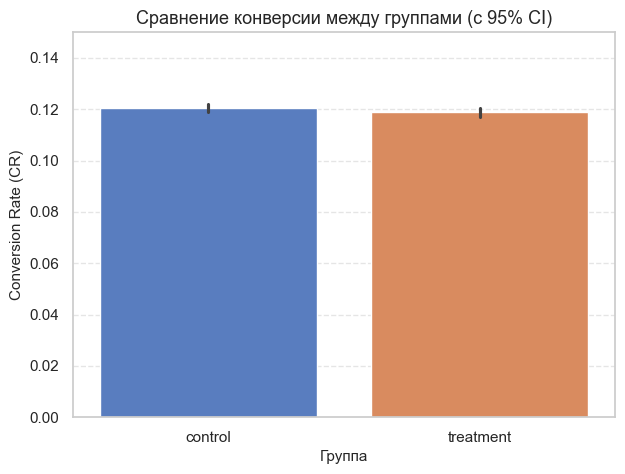

In [110]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x='group', 
    y='converted', 
    data=df_final, 
    errorbar=('ci', 95), # Строит 95% доверительный интервал ("усы")
    palette='muted'
)

plt.title('Сравнение конверсии между группами (с 95% CI)', fontsize=13)
plt.xlabel('Группа', fontsize=11)
plt.ylabel('Conversion Rate (CR)', fontsize=11)
plt.ylim(0, 0.15)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [111]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

print("--- Шаг 4: Статистический Z-тест для пропорций ---")

# Собираем количество успехов (конверсий) в каждой группе
successes = [
    df_final[df_final['group'] == 'control']['converted'].sum(),
    df_final[df_final['group'] == 'treatment']['converted'].sum()
]

# Собираем общее число пользователей в каждой группе
n_observations = [
    df_final[df_final['group'] == 'control']['converted'].count(),
    df_final[df_final['group'] == 'treatment']['converted'].count()
]

# 1. Проводим Z-тест
# alternative='two-sided' означает, что мы проверяем двустороннюю гипотезу (метрика изменилась в любую сторону)
z_stat, p_value = proportions_ztest(count=successes, nobs=n_observations, alternative='two-sided')

# 2. Расчет доверительного интервала для РАЗНОСТИ конверсий (Treatment - Control)
ci_low, ci_upp = confint_proportions_2indep(
    count1=successes[1], nobs1=n_observations[1],
    count2=successes[0], nobs2=n_observations[0],
    compare='diff', alpha=0.05
)

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"95% Доверительный интервал разности (Treatment - Control): [{ci_low:.5f}, {ci_upp:.5f}]")

# Финальный вердикт на основе альфы из Шага 1 (alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print(f"\nВердикт: p-value < {alpha}. Статистически значимые различия ОБНАРУЖЕНЫ! Отклоняем нулевую гипотезу (H0).")
else:
    print(f"\nВердикт: p-value >= {alpha}. Статистически значимых различий НЕ обнаружено. Нам не хватает оснований отклонить H0.")

--- Шаг 4: Статистический Z-тест для пропорций ---
Z-статистика: 1.3116
p-value: 0.1897
95% Доверительный интервал разности (Treatment - Control): [-0.00394, 0.00078]

Вердикт: p-value >= 0.05. Статистически значимых различий НЕ обнаружено. Нам не хватает оснований отклонить H0.
